In [1]:
import bmll2 as b2

import random
import math
import pandas as pd
import polars as pl
import numpy as np
from pandas import StringDtype

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import LogFormatterSciNotation

In [7]:
N                   = 20
trader_distribution = 'homogenous'
alpha               = 2
group               = 'day'
identifier          = f'{trader_distribution}_{N}_{group}_pl'
ticker              = 'GFI'
exchange            = 'XJSE'

In [8]:
b2.get_file(f'data/time_independence/{exchange}/{identifier}/{ticker}_{exchange}_time_independence_{identifier}.parquet')
impact = pd.read_parquet(f'{ticker}_{exchange}_time_independence_{identifier}.parquet')
impact.head()

,Date,trader id,metaorder id,Ticker,MIC,Start time,End time,Daily Volume,Intraday Volatility,20 AD volume,...,Mid-price after,Mid-price after (delayed),Mid-price before (1ms),Mid-price after (1ms),Mid-price after (1ms)(delayed),impact,impact (delayed),impact (1ms),impact (1ms)(delayed),duration (min)
0,2023-01-03,5,32,GFI,XJSE,2023-01-03 13:32:51.676233,2023-01-03 13:32:52.482839,896781.0,0.0293,896781.0,...,17954.5,17954.5,17955.5,17954.5,17954.5,-0.000056,-0.000056,-0.000056,-0.000056,0.013443
1,2023-01-03,16,5,GFI,XJSE,2023-01-03 09:25:14.678766,2023-01-03 09:31:09.265378,896781.0,0.0293,896781.0,...,18102.5,18102.5,18073.0,18100.5,18104.0,-0.001050,-0.001050,-0.001520,-0.001714,5.909777
2,2023-01-03,19,21,GFI,XJSE,2023-01-03 10:51:05.576095,2023-01-03 10:51:05.934473,896781.0,0.0293,896781.0,...,17909.0,17902.5,17910.5,17909.0,17907.5,0.000084,0.000447,0.000084,0.000168,0.005973
3,2023-01-03,13,22,GFI,XJSE,2023-01-03 11:26:44.616511,2023-01-03 11:29:30.074453,896781.0,0.0293,896781.0,...,17952.5,17960.0,17935.5,17952.5,17960.0,0.000947,0.001365,0.000947,0.001365,2.757632
4,2023-01-03,18,47,GFI,XJSE,2023-01-03 11:31:28.176361,2023-01-03 11:33:05.122227,896781.0,0.0293,896781.0,...,17959.0,17958.5,17968.0,17951.5,17959.0,0.000501,0.000529,0.000919,0.000501,1.615764


In [9]:
metaorder_size = np.sqrt(impact['volume traded'] / impact['20 AD volume'])
scaled_impact  = impact['impact'] / (impact['20 AD volatility'] * metaorder_size)
bins           = np.logspace(-3, 3, 100)
durations      = impact['duration (min)']
durations_bins = pd.cut(durations, bins = bins)

scaled_impact_bins_vals = scaled_impact.groupby(durations_bins, observed = False).mean()
durations_bins_centers  = [interval.mid for interval in scaled_impact_bins_vals.index.categories]

In [10]:
if ticker == 'GFI':
    color = 'purple'
else:
    color = 'olive'

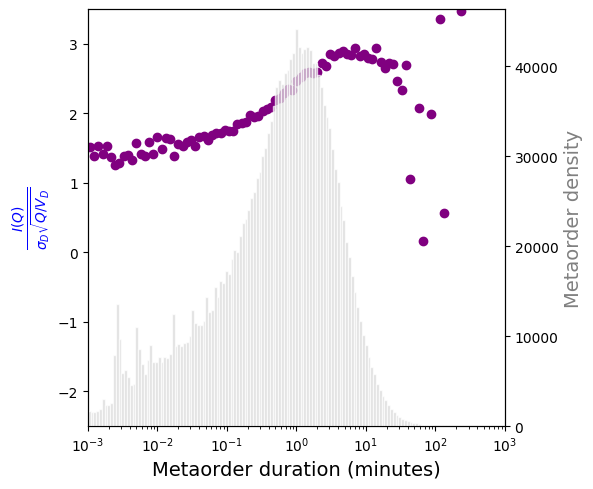

In [11]:
fig, ax1 = plt.subplots(figsize = (6, 6))

ax1.set_xscale('log')
ax1.set_xlim(1e-3, 1e3)
ax1.set_ylim(-2.5, 3.5)

ax1.scatter(durations_bins_centers, scaled_impact_bins_vals, color = color, marker = 'o')

ax1.set_xlabel('Metaorder duration (minutes)', fontsize = 14)
ax1.set_ylabel(r'$\frac{I(Q)}{\sigma_{D} \sqrt{Q/V_{D}}}$', fontsize = 14, color = 'blue')
ax1.xaxis.set_major_formatter(LogFormatterSciNotation(labelOnlyBase = False))

# Histogram (right axis)
ax2 = ax1.twinx()
bins = np.logspace(-3, 3, 150)
ax2.hist(durations, bins = bins, color = 'lightgray', edgecolor = 'white', alpha = 0.7)
ax2.set_ylabel('Metaorder density', fontsize = 14, color = 'gray')

ax1.set_box_aspect(1)
plt.tight_layout()
#plt.savefig(f'metaorder_duration_{ticker}.pdf')
#b2.put_file(f'metaorder_duration_{ticker}.pdf', 'figures')
#b2.get_file(f'metaorder_duration_{ticker}.pdf')

plt.show()